In [1]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import warnings
import pandas as pd
import gc
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams['font.size'] = 16         
plt.rcParams['axes.titlesize'] = 16   
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [3]:
storage_folder = '/net/vdesk/data2/deklerk/GAAP_data/flux_files'
processed_file = "/net/vdesk/data2/deklerk/GAAP_data/processed.txt"

In [4]:
with open(processed_file, "r") as f:
    processed = set(line.strip() for line in f)
print(processed)

{'102018213', '102020531', '102021490', '102022974', '102021499', '102019585', '102019596', '102021978', '102022475', '102021494', '102022971', '102020065', '102020055', '102018665', '102022484', '102021991', '102019594', '102021979', '102019130', '102021006', '102021007', '102021009', '102019590', '102021988', '102021491', '102019587', '102019125', '102020529', '102020536', '102021493', '102020059', '102020061', '102022478', '102020053', '102021012', '102020533', '102021983', '102020542', '102020064', '102021495', '102020056', '102021504', '102020527', '102021015', '102021013', '102021981', '102019591', '102021501', '102018211', '102021014', '102020063', '102021982', '102021020', '102021021', '102021502', '102018666', '102022485', '102019123', '102021492', '102020535', '102022481', '102018664', '102019593', '102018670', '102021010', '102020528', '102022482', '102022972', '102020054', '102021503', '102022474', '102022477', '102020537', '102019592', '102020062', '102022973', '102022483'

In [75]:
gc.collect()

35503

In [76]:
all_fluxes = None
stop_index = 130
total = 0
for i, tile_index in enumerate(processed):
    if i > stop_index:
        break
    if all_fluxes is None:
        all_fluxes = pd.read_csv(f'{storage_folder}/{tile_index}_fluxes.csv')
    else:
        fluxes = pd.read_csv(f'{storage_folder}/{tile_index}_fluxes.csv')
#     total += len(fluxes)
# print(total)
        all_fluxes = pd.concat([all_fluxes, fluxes], ignore_index=True)

In [77]:
print(len(all_fluxes))
all_fluxes

11467054


,id,ra,dec,weight_size,DES-Z,DES-Z_sigma,DES-G,DES-G_sigma,DES-I,DES-I_sigma,DES-R,DES-R_sigma,NIR-J,NIR-J_sigma,NIR-H,NIR-H_sigma,VIS,VIS_sigma,NIR-Y,NIR-Y_sigma
0,-595263194514976270,59.526319,-51.497627,0.702283,109705.184364,843.403010,2255.272718,208.909424,57111.206224,419.189939,10217.494071,219.377274,0.000000,1.735455e+18,0.000000,2.216093e+18,5545.657779,1.057216e+20,0.000000,2.409467e+18
1,-595260148514975739,59.526015,-51.497574,0.702283,95336.660632,843.350382,1897.155705,209.063834,44684.761059,419.273150,8186.227464,219.722907,0.000000,1.735597e+18,0.000000,2.216217e+18,4326.438220,8.513004e+19,0.000000,2.409379e+18
2,-594959316514975226,59.495932,-51.497523,0.702283,230.136372,840.444385,74.224014,208.930754,217.701993,417.557665,176.442776,217.790171,0.000000,1.735749e+18,0.000000,2.216414e+18,195.888958,8.049561e+19,0.000000,2.409907e+18
3,-595627051514975472,59.562705,-51.497547,0.702283,416.220544,845.470763,127.562662,209.484728,372.220826,420.270176,230.963740,219.702426,0.000000,1.736879e+18,0.000000,2.217572e+18,178.850449,3.339272e+19,0.000000,2.410814e+18
4,-594754738514974939,59.475474,-51.497494,0.702283,937.847603,841.071602,348.887417,207.105734,340.031798,419.474850,447.034818,218.001545,0.000000,1.736463e+18,0.000000,2.217119e+18,242.319762,7.365025e+19,0.000000,2.410217e+18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11467049,-652906703472483556,65.290670,-47.248356,0.702283,54.603621,618.787651,21.688910,144.974389,109.733716,459.919784,141.431846,223.485892,274.295942,4.708720e+02,668.847736,6.159547e+02,77.403308,4.764015e+01,-57.686397,4.688043e+02
11467050,-655008038472479126,65.500804,-47.247913,0.702283,243.851167,709.577235,52.099966,168.476353,158.528195,538.305433,95.003471,245.857988,841.936080,5.435127e+02,538.058342,6.098967e+02,97.926882,6.241369e+01,308.973578,4.947844e+02
11467051,-654511961472480023,65.451196,-47.248002,0.702283,-12.829653,665.131168,-36.317198,169.112333,192.425639,489.138942,-64.229412,245.784797,352.627882,4.832676e+02,438.163143,6.048140e+02,76.310064,5.308090e+01,546.598854,5.009849e+02
11467052,-654514648472476221,65.451465,-47.247622,0.702283,34.794782,664.189422,-19.212832,161.848885,18.977626,488.627074,77.780191,235.067443,387.443817,4.886024e+02,575.596506,6.101579e+02,70.855107,5.373712e+01,328.422178,5.041378e+02


In [8]:
all_fluxes.columns

Index(['id', 'ra', 'dec', 'weight_size', 'DES-Z', 'DES-Z_sigma', 'DES-G',
       'DES-G_sigma', 'DES-I', 'DES-I_sigma', 'DES-R', 'DES-R_sigma', 'NIR-J',
       'NIR-J_sigma', 'NIR-H', 'NIR-H_sigma', 'VIS', 'VIS_sigma', 'NIR-Y',
       'NIR-Y_sigma'],
      dtype='str')

In [87]:
from scipy.ndimage import gaussian_filter

153806


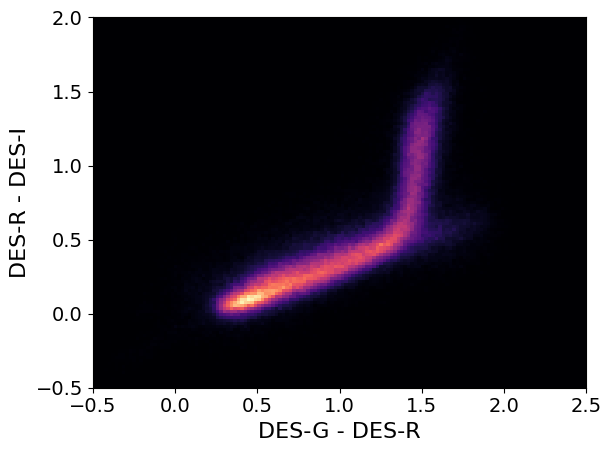

In [128]:
filter_1 = 'DES-G'   # e.g., master_table column name
filter_2 = 'DES-R'
filter_3 = filter_2
filter_4 = 'DES-I'

plot_error = True

# Compute colors from master_table fluxes
x_color = -2.5 * np.log10(all_fluxes[filter_1] / all_fluxes[filter_2])
y_color = -2.5 * np.log10(all_fluxes[filter_3] / all_fluxes[filter_4])

# Compute errors from sigma dictionary
xerr = 2.5 / np.log(10) * np.sqrt(
    (all_fluxes[f'{filter_1}_sigma'] / all_fluxes[filter_1])**2 +
    (all_fluxes[f'{filter_2}_sigma'] / all_fluxes[filter_2])**2
)
yerr = 2.5 / np.log(10) * np.sqrt(
    (all_fluxes[f'{filter_3}_sigma'] / all_fluxes[filter_3])**2 +
    (all_fluxes[f'{filter_4}_sigma'] / all_fluxes[filter_4])**2
)

gaap_error = xerr**2 + yerr**2
mask = (gaap_error < .01) & (np.isfinite(x_color)) & (np.isfinite(y_color))
# plt.errorbar(
#     x_color[mask], y_color[mask],
#     xerr=xerr[mask] * plot_error, yerr=yerr[mask] * plot_error,
#     fmt='o', c='b', ms=1, elinewidth=0.5, alpha=0.8, label='GAAP', rasterized=True
# )
H, xedges, yedges = np.histogram2d(x_color[mask], y_color[mask], bins=500)
# H[H>0] = np.log(H)[H>0]
# apply Gaussian smoothing
H_smooth = gaussian_filter(H, sigma=.5)
plt.imshow(
    H_smooth.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto'
)
# plt.hexbin(x_color[mask], y_color[mask], gridsize=500)
print(np.sum(mask))

plt.xlabel(f'{filter_1} - {filter_2}')
plt.ylabel(f'{filter_3} - {filter_4}')
plt.xlim(-.5, 2.5)
plt.ylim(-.5, 2)
# plt.grid(True)
plt.tight_layout()
plt.show()